![Obesity-and-Eating-Habits-header](header.png)

## 1. Project Overview

The goal of this project is to analyze and segment individuals based on their **lifestyle, dietary habits, and physical conditions** using the Obesity dataset. Rather than relying solely on traditional, predefined weight categories, this project leverages unsupervised machine learning techniques to uncover natural, hidden groupings within the population. 

By applying a **Gaussian Mixture Model (GMM)**, we will categorize individuals into distinct "health risk clusters" based on multidimensional data such as physical activity, daily caloric intake, transportation methods, and family history. Ultimately, this project aims to provide a deeper understanding of the behavioral and physiological profiles that contribute to obesity, which can inform more personalized health interventions and lifestyle recommendations.

## 2. Problem Statement
Obesity and related metabolic risks are driven by a complex interplay of genetic, dietary, and behavioral factors. Traditional diagnostic metrics often simplify this by looking primarily at **Body Mass Index (BMI) or broad weight classifications**, which fail to capture an individual's complete lifestyle profile (e.g., a person might be classified as overweight but maintain high physical activity and good hydration). 

The problem we seek to address is how to **accurately discover multidimensional behavioral patterns** without relying on predefined labels. By identifying distinct sub-populations based on comprehensive health and habit data, we can better understand the underlying risk profiles and tailor specific wellness strategies to each distinct cluster.

## 3. Data Overview



## 4. Modeling Section

In [10]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

In [2]:
# Load the dataset
df = pd.read_csv('ObesityDataSet.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [3]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


# Cleaning Dataset
Converting categorical variables to dummy variables

In [4]:
# Getting dummies for Gender, Age, Height, Weight, family_history_with_overweight, SMOKE, FAVC, NCP, CALC, MTRANS, and NObeyesdad variables

new_df = df[['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'SMOKE', 'FAVC', 'NCP', 'CALC', 'MTRANS', 'NObeyesdad']]
df_encoded = pd.get_dummies(new_df, columns = ['Gender', 'family_history_with_overweight', 'SMOKE', 'FAVC', 'NCP', 'CALC', 'MTRANS', 'NObeyesdad'])
X = df_encoded
df_encoded.head()

,Age,Height,Weight,Gender_Female,Gender_Male,family_history_with_overweight_no,family_history_with_overweight_yes,SMOKE_no,SMOKE_yes,FAVC_no,...,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,NObeyesdad_Insufficient_Weight,NObeyesdad_Normal_Weight,NObeyesdad_Obesity_Type_I,NObeyesdad_Obesity_Type_II,NObeyesdad_Obesity_Type_III,NObeyesdad_Overweight_Level_I,NObeyesdad_Overweight_Level_II
0,21.0,1.62,64.0,True,False,False,True,True,False,True,...,False,True,False,False,True,False,False,False,False,False
1,21.0,1.52,56.0,True,False,False,True,False,True,True,...,False,True,False,False,True,False,False,False,False,False
2,23.0,1.80,77.0,False,True,False,True,True,False,True,...,False,True,False,False,True,False,False,False,False,False
3,27.0,1.80,87.0,False,True,True,False,True,False,True,...,False,False,True,False,False,False,False,False,True,False
4,22.0,1.78,89.8,False,True,True,False,True,False,True,...,False,True,False,False,False,False,False,False,False,True


# Using Gaussian Mixtures 

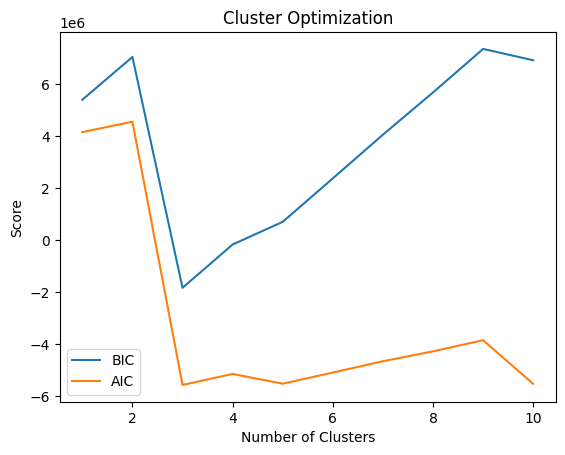

In [9]:
# Prepare Data 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find the ideal number of clusters
n_components = np.arange(1, 11)
models = [GaussianMixture(n, covariance_type='full', random_state=42).fit(X_scaled)
          for n in n_components]

plt.plot(n_components, [m.bic(X_scaled) for m in models], label='BIC')
plt.plot(n_components, [m.aic(X_scaled) for m in models], label='AIC')
plt.legend(loc='best')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Cluster Optimization')
plt.show()

In [6]:
# 1. Fit the final model with 3 clusters
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X_scaled)

# 2. Assign labels back to your original (non-scaled) dataframe
df['Cluster'] = gmm.predict(X_scaled)

# 3. Calculate the mean for each cluster
cluster_profiles = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_profiles)

               Age    Height      Weight      FCVC       NCP      CH2O  \
Cluster                                                                  
0        23.645033  1.696782   76.509825  2.299450  2.708477  1.979625   
1        25.532302  1.710611  104.944703  2.636163  2.643037  2.060042   
2        19.314429  1.672310   49.713944  2.562409  3.488342  1.670620   

              FAF       TUE  
Cluster                      
0        1.076189  0.680431  
1        0.889245  0.616407  
2        2.000000  1.000000  


In [8]:
# View the probability of the first 5 people belonging to each cluster
probabilities = gmm.predict_proba(X_scaled)
prob_df = pd.DataFrame(probabilities, columns=['Prob_Cluster_0', 'Prob_Cluster_1', 'Prob_Cluster_2'])
prob_df.head()

,Prob_Cluster_0,Prob_Cluster_1,Prob_Cluster_2
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


# t-SNE Visualization of Health Cluster Data

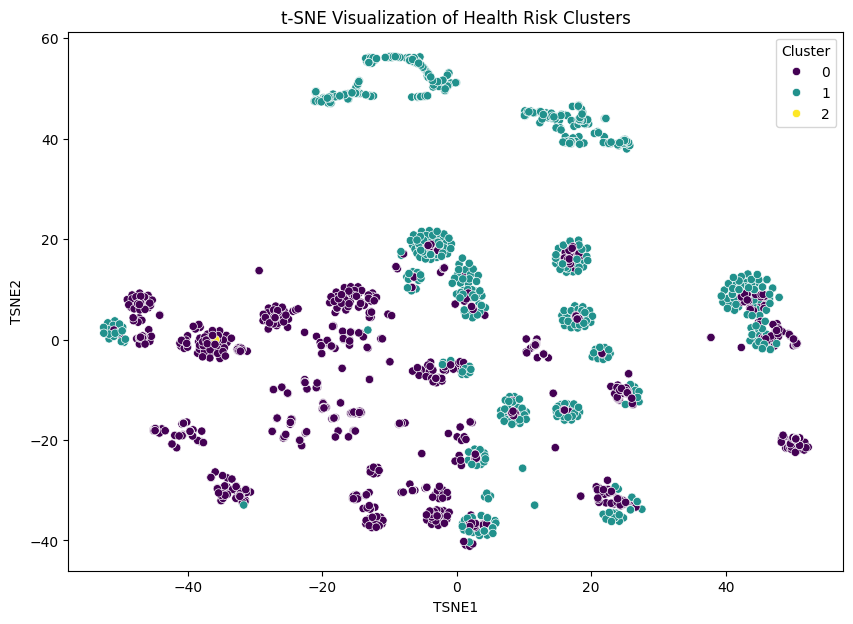

In [15]:
# Initialize t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')

# Fit and transform the scaled data
X_tsne = tsne.fit_transform(X_scaled)

# Create a plot
tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['Cluster'] = gmm.predict(X_scaled) 

# 4. Plot the results
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='TSNE1', y='TSNE2',
    hue='Cluster',
    palette='viridis',
    data=tsne_df,
    legend='full',
)

plt.title('t-SNE Visualization of Health Risk Clusters')
plt.show()

## Explanation